<a href="https://colab.research.google.com/github/pj72181/project/blob/main/01_python_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("NorthStar Python notebook started successfully")

NorthStar Python notebook started successfully


In [5]:
from google.colab import files

uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


In [6]:
import os

os.listdir()


['.config',
 'deliveries.csv',
 'orders.csv',
 'hubs.csv',
 'customers.csv',
 'app_events.csv',
 'data_dictionary.csv',
 'complaints.csv',
 'incidents.csv',
 'vehicles.csv',
 'drivers.csv',
 'sample_data']

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")
app_events = pd.read_csv("app_events.csv")
data_dictionary = pd.read_csv("data_dictionary.csv")

print("All NorthStar dataset files loaded successfully")

All NorthStar dataset files loaded successfully


In [8]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Drivers:", drivers.shape)
print("Vehicles:", vehicles.shape)
print("Hubs:", hubs.shape)
print("Complaints:", complaints.shape)
print("Incidents:", incidents.shape)
print("App Events:", app_events.shape)


Customers: (650, 9)
Orders: (1250, 11)
Deliveries: (950, 13)
Drivers: (170, 8)
Vehicles: (120, 8)
Hubs: (8, 5)
Complaints: (320, 10)
Incidents: (280, 7)
App Events: (640, 10)


In [9]:
datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
    print("\n==============================")
    print("DATASET:", name.upper())
    print("==============================")

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nData Types:")
    print(df.dtypes)


DATASET: CUSTOMERS

Columns:
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

Missing Values:
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64

Data Types:
customer_id              object
age                       int64
home_zone                object
customer_type            object
signup_date              object
loyalty_score           float64
app_engagement_score    float64
preferred_channel        object
account_status           object
dtype: object

DATASET: ORDERS

Columns:
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

Missing V

In [10]:
delivery_status_counts = deliveries["delivery_status"].value_counts()

print(delivery_status_counts)

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


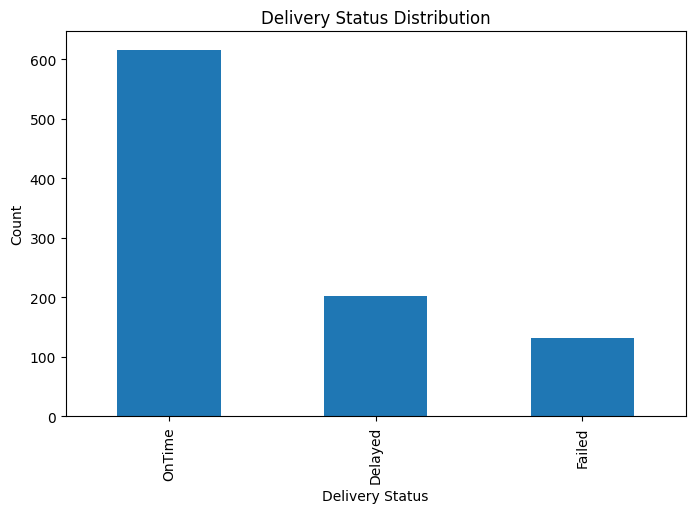

In [11]:
delivery_status_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Count")

plt.show()

delivery_status  Delayed  Failed  OnTime
hub_id                                  
H01                19.12   12.50   68.38
H02                24.53    9.43   66.04
H03                19.33    9.24   71.43
H04                22.05   12.60   65.35
H05                21.74   20.00   58.26
H06                25.96   14.42   59.62
H07                21.74   12.17   66.09
H08                17.19   20.31   62.50


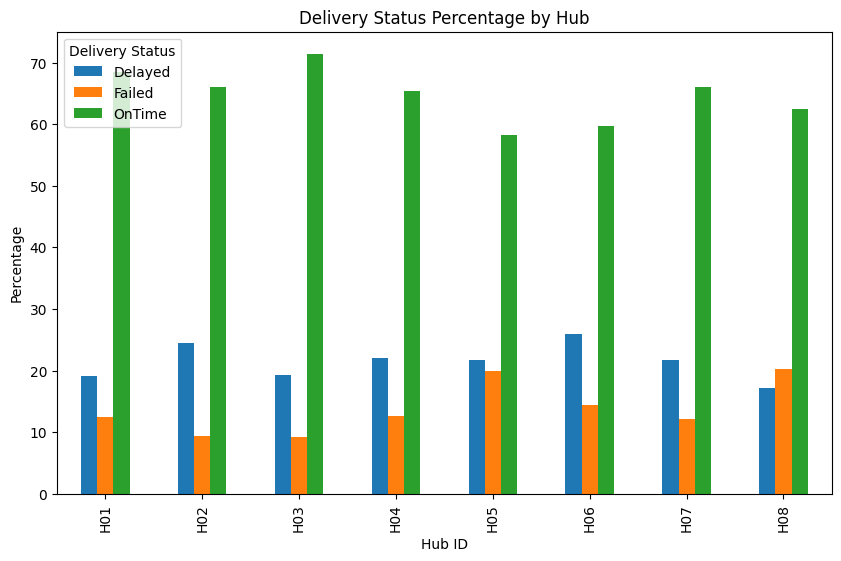

In [12]:
hub_delivery_status = pd.crosstab(
    deliveries["hub_id"],
    deliveries["delivery_status"],
    normalize="index"
) * 100

print(hub_delivery_status.round(2))

hub_delivery_status.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Delivery Status Percentage by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Percentage")
plt.legend(title="Delivery Status")
plt.show()

In [13]:
hub_summary = deliveries.merge(hubs, on="hub_id", how="left")

hub_zone_status = pd.crosstab(
    [hub_summary["hub_id"], hub_summary["hub_name"], hub_summary["zone"]],
    hub_summary["delivery_status"],
    normalize="index"
) * 100

print(hub_zone_status.round(2))


delivery_status                  Delayed  Failed  OnTime
hub_id hub_name       zone                              
H01    North Exchange North        19.12   12.50   68.38
H02    South Link     South        24.53    9.43   66.04
H03    East Dock      East         19.33    9.24   71.43
H04    West Gate      West         22.05   12.60   65.35
H05    Central Core   Central      21.74   20.00   58.26
H06    Airport Hub    Airport      25.96   14.42   59.62
H07    Riverside Hub  Riverside    21.74   12.17   66.09
H08    Midtown Relay  Central      17.19   20.31   62.50


In [14]:
override_by_hub = hub_summary.groupby(
    ["hub_id", "hub_name", "zone"]
)["manual_route_override_count"].mean().sort_values(ascending=False)

print(override_by_hub.round(2))

hub_id  hub_name        zone     
H08     Midtown Relay   Central      1.11
H07     Riverside Hub   Riverside    1.05
H01     North Exchange  North        1.03
H05     Central Core    Central      0.95
H02     South Link      South        0.92
H06     Airport Hub     Airport      0.91
H03     East Dock       East         0.89
H04     West Gate       West         0.87
Name: manual_route_override_count, dtype: float64


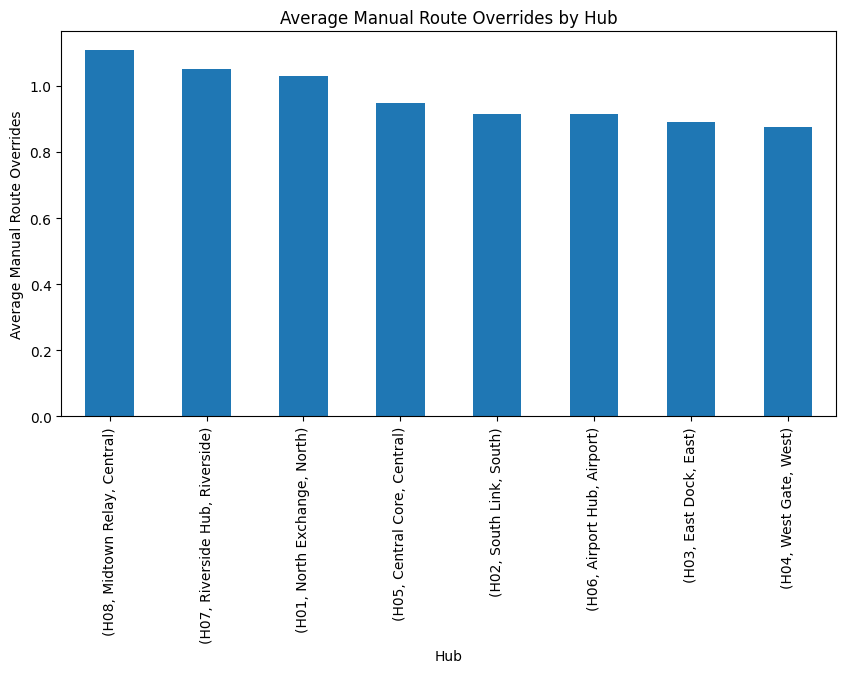

In [15]:
override_by_hub.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Manual Route Overrides by Hub")
plt.xlabel("Hub")
plt.ylabel("Average Manual Route Overrides")
plt.show()

In [16]:
complaint_type_counts = complaints["complaint_type"].value_counts()

print(complaint_type_counts)

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64


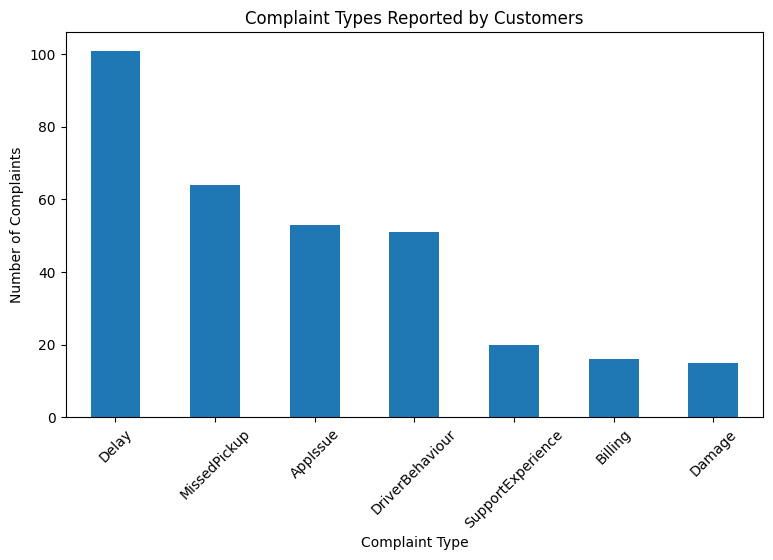

In [17]:
complaint_type_counts.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Complaint Types Reported by Customers")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

In [18]:
complaint_severity = complaints["severity"].value_counts()

print(complaint_severity)

severity
Medium    172
High       77
Low        71
Name: count, dtype: int64


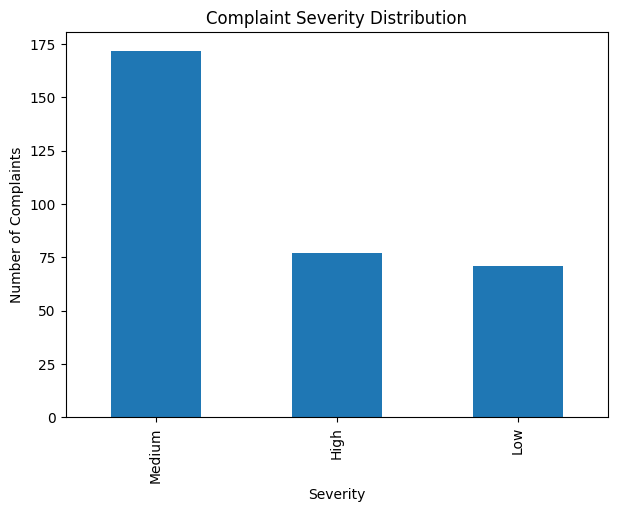

In [19]:
complaint_severity.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Complaint Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Complaints")
plt.show()

In [20]:
total_compensation = complaints["compensation_amount"].sum()

average_compensation = complaints["compensation_amount"].mean()

print("Total Compensation:", round(total_compensation, 2))
print("Average Compensation:", round(average_compensation, 2))

Total Compensation: 6158.19
Average Compensation: 20.26


In [21]:
compensation_by_type = complaints.groupby(
    "complaint_type"
)["compensation_amount"].mean().sort_values(ascending=False)

print(compensation_by_type.round(2))

complaint_type
Damage               23.98
Billing              23.87
MissedPickup         22.59
DriverBehaviour      21.15
AppIssue             19.61
Delay                18.05
SupportExperience    17.12
Name: compensation_amount, dtype: float64


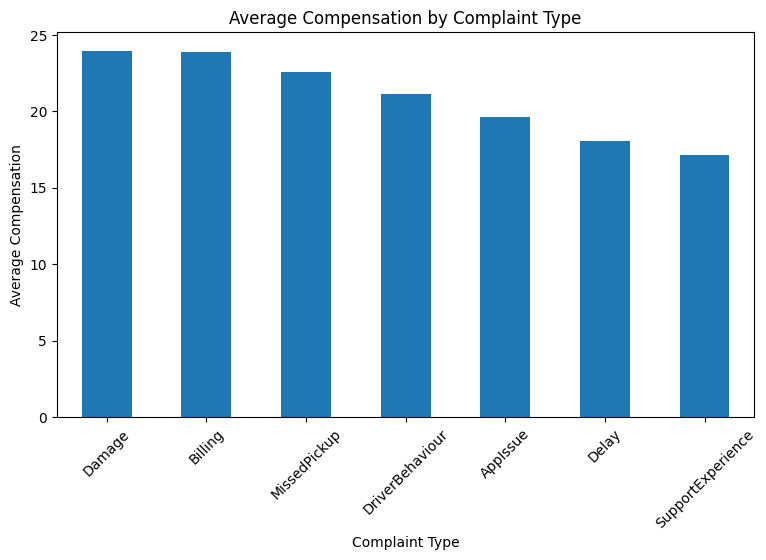

In [22]:
compensation_by_type.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average Compensation by Complaint Type")
plt.xlabel("Complaint Type")
plt.ylabel("Average Compensation")
plt.xticks(rotation=45)
plt.show()

In [23]:
incident_type_counts = incidents["incident_type"].value_counts()

print(incident_type_counts)

incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64


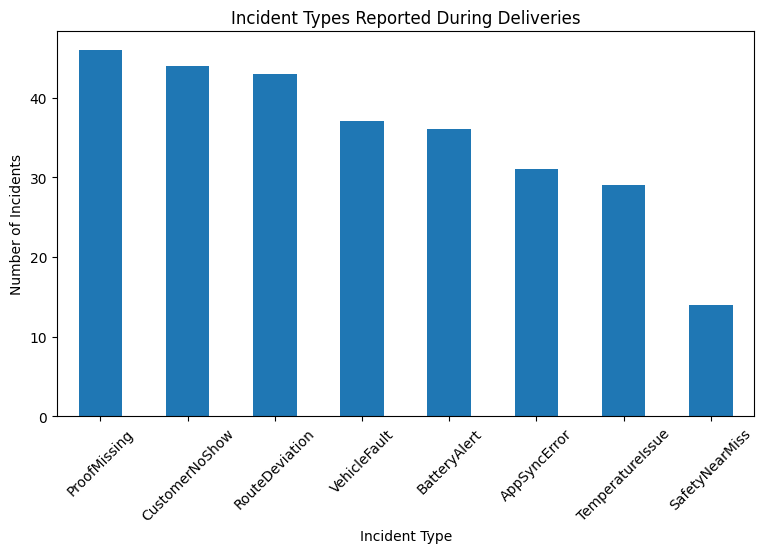

In [24]:
incident_type_counts.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Incident Types Reported During Deliveries")
plt.xlabel("Incident Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.show()

In [25]:
incident_delivery = incidents.merge(deliveries, on="delivery_id", how="left")

incident_delivery_status = pd.crosstab(
    incident_delivery["incident_type"],
    incident_delivery["delivery_status"]
)

print(incident_delivery_status)

delivery_status   Delayed  Failed  OnTime
incident_type                            
AppSyncError            9       5      17
BatteryAlert            6       5      25
CustomerNoShow         10       3      31
ProofMissing            9       6      31
RouteDeviation          8       4      31
SafetyNearMiss          2       2      10
TemperatureIssue        6       6      17
VehicleFault            5       3      29


In [26]:
incident_delivery_percent = pd.crosstab(
    incident_delivery["incident_type"],
    incident_delivery["delivery_status"],
    normalize="index"
) * 100

print(incident_delivery_percent.round(2))

delivery_status   Delayed  Failed  OnTime
incident_type                            
AppSyncError        29.03   16.13   54.84
BatteryAlert        16.67   13.89   69.44
CustomerNoShow      22.73    6.82   70.45
ProofMissing        19.57   13.04   67.39
RouteDeviation      18.60    9.30   72.09
SafetyNearMiss      14.29   14.29   71.43
TemperatureIssue    20.69   20.69   58.62
VehicleFault        13.51    8.11   78.38


In [27]:
vehicle_status_counts = vehicles["maintenance_status"].value_counts()
print(vehicle_status_counts)

maintenance_status
Active       67
InRepair     36
Scheduled    17
Name: count, dtype: int64


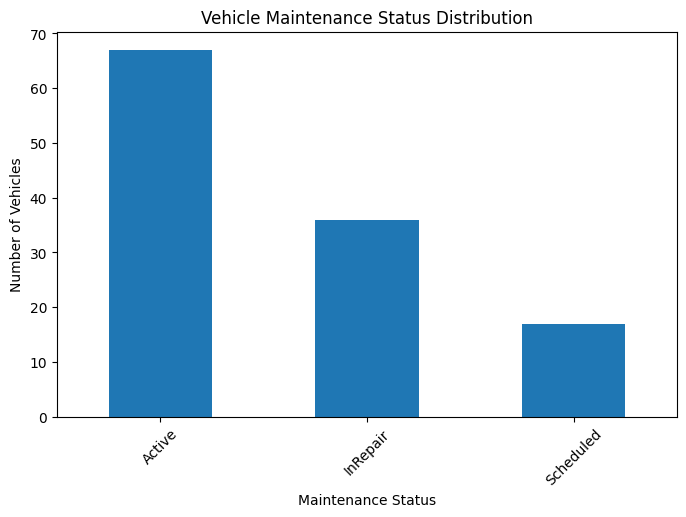

In [28]:
vehicle_status_counts.plot(kind="bar", figsize=(8,5))

plt.title("Vehicle Maintenance Status Distribution")
plt.xlabel("Maintenance Status")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

In [29]:
non_active = vehicles[vehicles["maintenance_status"] != "Active"].shape[0]
total_vehicles = vehicles.shape[0]
non_active_percent = (non_active / total_vehicles) * 100

print("Non-active or maintenance-related vehicles:", non_active)
print("Percentage:", round(non_active_percent, 2))

Non-active or maintenance-related vehicles: 53
Percentage: 44.17


In [30]:
print(vehicles["battery_health_pct"].describe())

count    116.000000
mean      76.785345
std       12.698985
min       42.000000
25%       68.200000
50%       78.050000
75%       85.775000
max      100.000000
Name: battery_health_pct, dtype: float64


In [31]:
low_battery_vehicles = vehicles[vehicles["battery_health_pct"] < 70]

print(low_battery_vehicles[["vehicle_id", "vehicle_type", "assigned_zone", "battery_health_pct", "maintenance_status"]])
print("Low battery vehicles:", low_battery_vehicles.shape[0])

    vehicle_id vehicle_type assigned_zone  battery_health_pct  \
1         V002           EV       AIRPORT                67.9   
4         V005     CargoVan          West                58.6   
6         V007       Diesel       AIRPORT                68.6   
8         V009     CargoVan         South                68.8   
9         V010     CargoVan         NORTH                50.7   
11        V012       Hybrid         SOUTH                56.2   
12        V013     CargoVan          WEST                68.3   
15        V016           EV          WEST                63.5   
24        V025       Diesel       AIRPORT                42.0   
36        V037     CargoVan         South                56.6   
38        V039           EV          EAST                69.5   
48        V049       Diesel          East                55.9   
60        V061       Diesel         South                60.3   
63        V064     CargoVan          WEST                67.3   
66        V067       Hybr

In [32]:
vehicles["assigned_zone_clean"] = vehicles["assigned_zone"].str.strip().str.lower()

zone_mapping = {
    "north": "North",
    "south": "South",
    "east": "East",
    "west": "West",
    "central": "Central",
    "ctr": "Central",
    "airport": "Airport",
    "riverside": "Riverside"
}

vehicles["assigned_zone_clean"] = vehicles["assigned_zone_clean"].replace(zone_mapping)

print(vehicles[["assigned_zone", "assigned_zone_clean"]].drop_duplicates().sort_values("assigned_zone"))

   assigned_zone assigned_zone_clean
1        AIRPORT             Airport
14       Airport             Airport
20       CENTRAL             Central
5        Central             Central
46           Ctr             Central
22          EAST                East
23          East                East
9          NORTH               North
0          North               North
3      RiverSide           Riverside
10     Riverside           Riverside
11         SOUTH               South
8          South               South
12          WEST                West
4           West                West
2          north               North


In [33]:
low_battery_by_zone = vehicles[vehicles["battery_health_pct"] < 70].groupby(
    "assigned_zone_clean"
)["vehicle_id"].count().sort_values(ascending=False)

print(low_battery_by_zone)

assigned_zone_clean
South        8
East         6
Airport      6
West         6
Central      5
Riverside    2
North        2
Name: vehicle_id, dtype: int64
